# **Customers analysis** table of contents
1. Customer Overview
2. Purchase Frequency
3. Repeat Customers
4. Customer Value
5. Recency & Activity
6. Customer Satisfaction
7. Logistics Experience
8. Geographic Distribution
9. RFM Preparation
10. Key Customer Insights

## 1. Customer Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"..\data\gold\olist_"
gold_orders = pd.read_parquet(file_path + "orders.parquet")
gold_products = pd.read_parquet(file_path + "products.parquet")
gold_customers = pd.read_parquet(file_path + "customers.parquet")


In [4]:
total_customers = gold_customers["customer_unique_id"].nunique()

repeat_rate = (
    gold_customers["is_repeat_customer"].mean() * 100
)

avg_orders_per_customer = (
    gold_customers["nb_orders"].mean()
)

avg_customer_value = (
    gold_customers["total_spent"].mean()
)

median_customer_value = (
    gold_customers["total_spent"].median()
)

print(f"Total unique customers    : {total_customers:,}")
print(f"Repeat customer rate      : {repeat_rate:.2f}%")
print(f"Average orders/customer   : {avg_orders_per_customer:.2f}")
print(f"Average customer value    : {avg_customer_value:.2f}")
print(f"Median customer value     : {median_customer_value:.2f}")

Total unique customers    : 96,096
Repeat customer rate      : 3.12%
Average orders/customer   : 1.03
Average customer value    : 166.04
Median customer value     : 107.94


## 2. Purchase Frequency

In [ ]:
order_frequency = (
    gold_customers["nb_orders"]
    .value_counts()
    .sort_index()
)

order_frequency

nb_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [27]:
def cat_orders (nb_orders):
    if nb_orders == 1 :
        return str(nb_orders) 
    else :
        return '+1'

gold_customers["nb_orders_cat"] = gold_customers["nb_orders"].map(cat_orders)

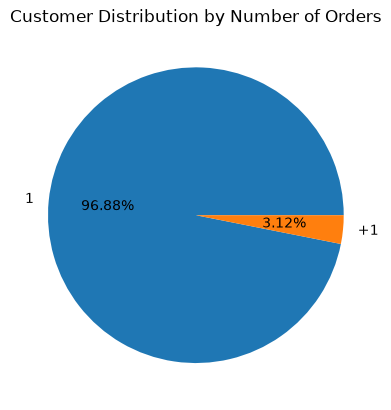

In [28]:
gold_customers["nb_orders_cat"].value_counts().plot(
    kind="pie", autopct="%.2f%%", ylabel=""
)

plt.title("Customer Distribution by Number of Orders")
plt.show()


## 3. Repeat Customers

In [31]:
repeat_customers = (
    gold_customers["is_repeat_customer"].value_counts(normalize=True).mul(100)
)

repeat_customers.index = repeat_customers.index.map(
    {False: "One-time customer", True: "Repeat customer"}
)

repeat_customers

is_repeat_customer
One-time customer    96.881244
Repeat customer       3.118756
Name: proportion, dtype: float64

In [32]:
gold_customers.groupby("is_repeat_customer")[
    ["nb_orders", "total_spent", "avg_order_value"]
].mean()


,nb_orders,total_spent,avg_order_value
is_repeat_customer,,,
False,1.000000,161.434051,161.434051
True,2.116116,308.478585,149.006763


## 4. Customer Value

In [33]:
gold_customers["total_spent"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    95420.000000
mean       166.040172
std        228.320333
min          9.590000
50%        107.940000
75%        183.220000
90%        319.110000
95%        473.820500
99%       1113.570200
max      13664.080000
Name: total_spent, dtype: float64

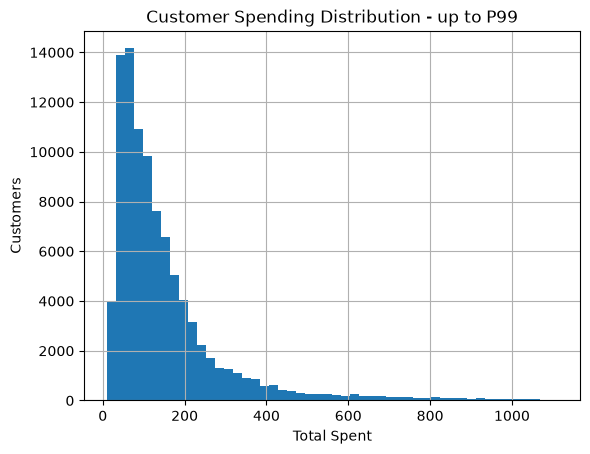

In [34]:
limit = gold_customers["total_spent"].quantile(0.99)

gold_customers.loc[gold_customers["total_spent"] <= limit, "total_spent"].hist(bins=50)

plt.title("Customer Spending Distribution - up to P99")
plt.xlabel("Total Spent")
plt.ylabel("Customers")
plt.show()


In [35]:
gold_customers.nlargest(10, "total_spent")[
    ["customer_unique_id", "nb_orders", "total_spent", "avg_order_value"]
]


,customer_unique_id,nb_orders,total_spent,avg_order_value
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310
26205,459bef486812aa25204be022145caa62,1,6922.21,6922.210
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.660
24121,4007669dec559734d6f53e029e360987,1,6081.54,6081.540
35070,5d0a2980b292d049061542014e8960bf,1,4809.44,4809.440
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.340
27441,48e1ac109decbb87765a3eade6854098,1,4681.78,4681.780


## 5. Recency & Activity

In [36]:
gold_customers["recency_days"].describe()

count    96096.000000
mean       287.735691
std        153.414676
min          0.000000
25%        163.000000
50%        268.000000
75%        397.000000
max        772.000000
Name: recency_days, dtype: float64

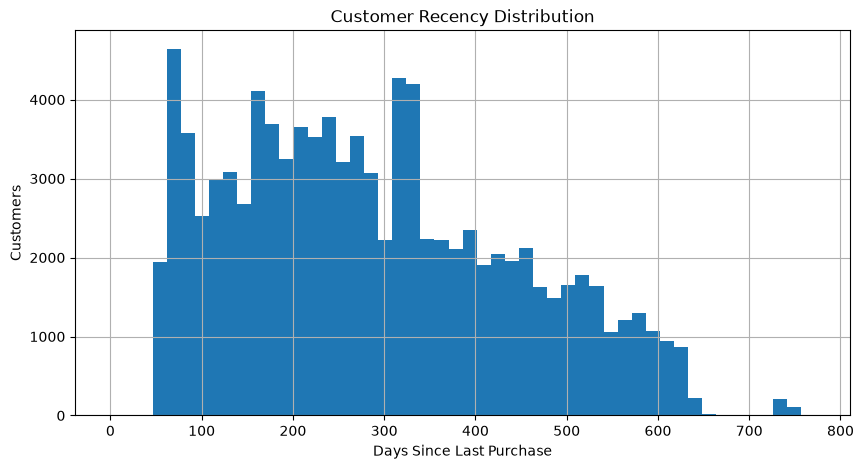

In [37]:
plt.figure(figsize=(10, 5))

gold_customers["recency_days"].hist(bins=50)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")
plt.show()


In [38]:
gold_customers[["recency_days", "nb_orders", "total_spent"]].corr()


,recency_days,nb_orders,total_spent
recency_days,1.000000,-0.024859,-0.003078
nb_orders,-0.024859,1.000000,0.122237
total_spent,-0.003078,0.122237,1.000000


 La corrélation entre recency_days et nb_orders est très faible (-0,025), tout comme celle entre récence et dépenses (-0,003). Dans ce dataset, le fait d’avoir acheté récemment n’est donc pratiquement pas associé au nombre de commandes ou au montant total dépensé. La relation entre nb_orders et total_spent est positive mais faible (0,122) : les clients qui commandent davantage ont tendance à dépenser plus, mais le nombre de commandes n’explique qu’une petite partie des différences de valeur client.

## 6. Customer Satisfaction

In [39]:
gold_customers["avg_review_score"].describe()

count    95380.000000
mean         4.084963
std          1.341661
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: avg_review_score, dtype: float64

In [40]:
gold_customers.groupby("is_repeat_customer")["avg_review_score"].mean()


is_repeat_customer
False    4.083979
True     4.115400
Name: avg_review_score, dtype: float64

La note moyenne est de 4,08/5 pour les clients ayant commandé une seule fois contre 4,12/5 pour les clients récurrents. L’écart est très faible. On ne peut donc pas conclure, à ce stade, que la satisfaction mesurée par les avis explique fortement le réachat.

## 7. Logistics Experience

In [41]:
gold_customers.groupby("is_repeat_customer")[
    ["late_order_rate", "avg_delivery_days", "avg_delivery_delay_days"]
].mean()

,late_order_rate,avg_delivery_days,avg_delivery_delay_days
is_repeat_customer,,,
False,0.066424,12.110670,-11.825420
True,0.056024,11.880466,-12.573767


Les clients récurrents présentent un taux de retard légèrement inférieur : 5,60 % contre 6,64 %. Leur délai moyen de livraison est également légèrement plus court (11,88 jours contre 12,11). Enfin, leur avg_delivery_delay_days est plus négatif (-12,57 contre -11,83), ce qui signifie qu’ils reçoivent en moyenne leurs commandes un peu plus tôt par rapport à la date estimée. La différence existe, mais reste relativement faible.

In [42]:
gold_customers.groupby("has_logistics_issues")[
    ["avg_review_score", "nb_orders", "total_spent"]
].mean()


,avg_review_score,nb_orders,total_spent
has_logistics_issues,,,
False,4.208996,1.036761,165.223584
True,2.261960,1.006593,177.752751


Les clients ayant rencontré des problèmes logistiques attribuent une note moyenne d’environ 2,26/5, contre 4,21/5 pour les autres clients. La qualité logistique semble donc fortement associée à la satisfaction client. En revanche, le nombre moyen de commandes reste très proche entre les deux groupes (1,01 contre 1,04), ce qui ne permet pas encore d’établir un impact clair des problèmes logistiques sur la fidélisation.

## 8. Geographic Distribution

In [43]:
customers_by_state = (
    gold_customers["customer_state"]
    .value_counts()
)

customers_by_state.head(15)

customer_state
SP    40295
RJ    12377
MG    11255
RS     5277
PR     4882
SC     3529
BA     3276
DF     2073
ES     1963
GO     1951
PE     1604
CE     1311
PA      949
MT      875
MA      725
Name: count, dtype: int64

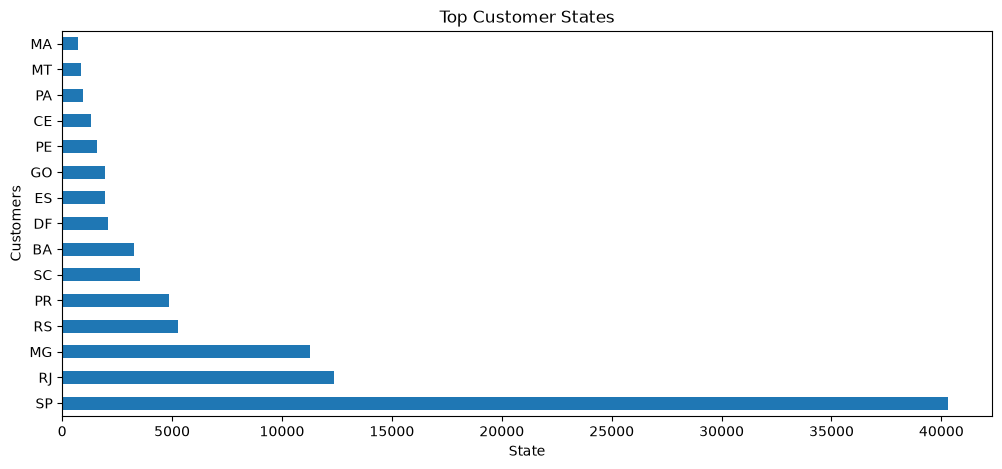

In [45]:
customers_by_state.head(15).plot(kind="barh", figsize=(12, 5))

plt.title("Top Customer States")
plt.xlabel("State")
plt.ylabel("Customers")
plt.show()


In [52]:
state_analysis = gold_customers.groupby("customer_state", as_index=False).agg(
    customers=("customer_unique_id", "nunique"),
    total_spent=("total_spent", "sum"),
    avg_customer_value=("total_spent", "mean"),
    repeat_rate=("is_repeat_customer", "mean"),
    avg_review_score=("avg_review_score", "mean"),
    late_order_rate=("late_order_rate", "mean"),
)

state_analysis["repeat_rate"] *= 100

state_analysis.sort_values("total_spent", ascending=False).head(15)


,customer_state,customers,total_spent,avg_customer_value,repeat_rate,avg_review_score,late_order_rate
25,SP,40295,5923525.68,148.184462,3.241097,4.172419,0.043949
18,RJ,12377,2128670.70,173.118957,3.409550,3.874982,0.11683
10,MG,11255,1856188.62,166.101890,3.056419,4.134125,0.04518
22,RS,5277,886076.83,168.808693,3.202577,4.133863,0.059282
17,PR,4882,801456.69,165.590225,3.052028,4.182071,0.039704
4,BA,3276,611457.60,187.794103,2.869353,3.856941,0.117175
23,SC,3529,609195.96,173.659054,2.720317,4.073791,0.080122
6,DF,2073,352571.41,171.151170,3.039074,4.071365,0.053304
8,GO,1951,348677.96,179.638310,3.331625,4.037410,0.064326
7,ES,1963,324668.66,166.070926,2.903719,4.028666,0.10613


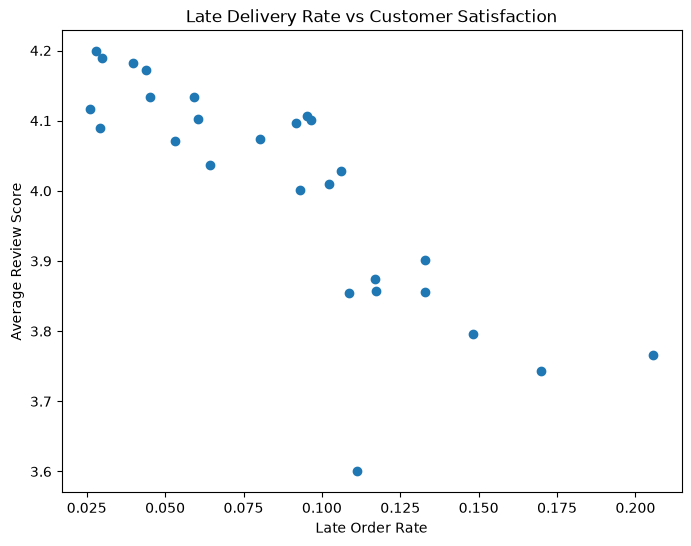

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(state_analysis["late_order_rate"], state_analysis["avg_review_score"])

plt.xlabel("Late Order Rate")
plt.ylabel("Average Review Score")
plt.title("Late Delivery Rate vs Customer Satisfaction")

plt.show()


L’activité est fortement concentrée dans l’État de São Paulo, qui rassemble le plus grand nombre de clients et génère le montant total de dépenses le plus élevé. Toutefois, les États présentant la plus forte valeur moyenne par client ne sont pas nécessairement ceux ayant le plus grand volume de clients. Des différences importantes apparaissent également dans la performance logistique : certains États tels que Maranhão, Ceará, Bahia et Rio de Janeiro affichent des taux de retard supérieurs à 10 %. Ces États présentent généralement des notes moyennes plus faibles, renforçant l’hypothèse d’une relation négative entre les retards de livraison et la satisfaction client.

## 9. RFM Preparation

In [48]:
rfm = gold_customers[
    ["customer_unique_id", "recency_days", "nb_orders", "total_spent"]
].copy()

rfm.columns = ["customer_unique_id", "recency", "frequency", "monetary"]


In [50]:
rfm.to_parquet(file_path+"rfm.parquet")

# Conclusion générale — Customer Analysis

 L’analyse client met en évidence une base très largement composée de clients occasionnels : **96,88 % des clients n’ont effectué qu’une seule commande**, contre seulement **3,12 % de clients récurrents**. La fidélisation apparaît donc comme l’un des principaux enjeux du business.

 Les clients récurrents présentent une satisfaction légèrement supérieure et une expérience logistique un peu meilleure, mais les écarts restent faibles. En revanche, les **problèmes logistiques sont fortement associés à une baisse de satisfaction** : les clients concernés ont une note moyenne d’environ **2,26/5**, contre **4,21/5** pour les autres.

 L’activité est également très concentrée géographiquement, notamment dans l’État de **São Paulo**, qui regroupe le plus grand nombre de clients et génère la plus forte dépense totale. À l’inverse, certains États moins importants en volume affichent une **valeur moyenne par client plus élevée**, montrant que volume et valeur client ne se confondent pas.

 Des différences régionales importantes apparaissent aussi sur la logistique. Plusieurs États, notamment `MA`, `CE`, `BA`, `RJ`, `PA` et `ES`, présentent des taux de retard supérieurs à 10 %, généralement associés à des notes moyennes plus faibles.

 Globalement, les résultats suggèrent donc trois axes majeurs : **améliorer la rétention client, réduire les problèmes logistiques et mieux identifier les segments à forte valeur**. Ces constats constituent une bonne base pour la prochaine étape : la **segmentation RFM et marketing des clients**.